<a href="https://colab.research.google.com/github/venkata18167/CSA6102-DIGITAL-FORENSICS-AND-CYBERCRIME-INVESTIGATION/blob/main/16_exp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

========== RANSOMWARE FAMILY DATABASE ==========

     Family                                         Domain              IP  \
0  WannaCry  iuqerfsodp9ifjaposdfjhgosurijfaewrwergwea.com    192.168.1.10   
1   LockBit                            lockbit-support.com       10.0.0.15   
2     REvil                               revil-help.onion     172.16.0.25   
3     Conti                                 conti-help.net  192.168.100.20   
4      Ryuk                                  ryuk-help.com    192.168.5.25   

  Extension            RansomNote  
0    .WNCRY    Please Read Me.txt  
1  .lockbit  Restore-My-Files.txt  
2    .revil            README.txt  
3    .conti      CONTI_README.txt  
4      .ryk        RyukReadMe.txt  

Database saved as ransomware_family_database.csv

========== IoC Indicators ==========

Family      : WannaCry
Domain      : iuqerfsodp9ifjaposdfjhgosurijfaewrwergwea.com
IP Address  : 192.168.1.10
Extension   : .WNCRY
Ransom Note : Please Read Me.txt
------------

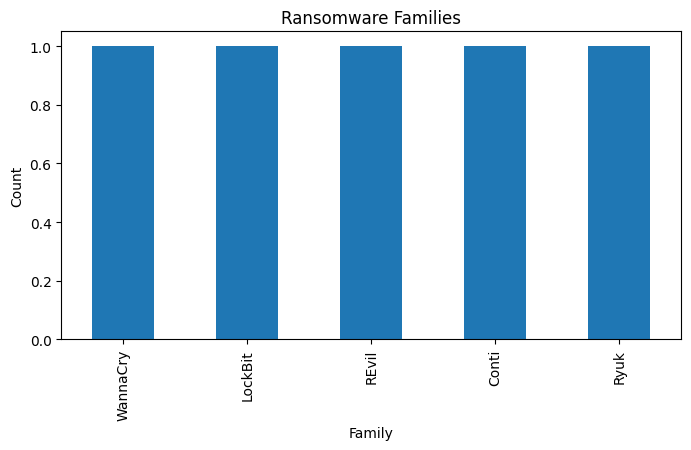

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Experiment Completed Successfully.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
ransomware_db = [
    {
        "Family":"WannaCry",
        "Domain":"iuqerfsodp9ifjaposdfjhgosurijfaewrwergwea.com",
        "IP":"192.168.1.10",
        "Extension":".WNCRY",
        "RansomNote":"Please Read Me.txt"
    },

    {
        "Family":"LockBit",
        "Domain":"lockbit-support.com",
        "IP":"10.0.0.15",
        "Extension":".lockbit",
        "RansomNote":"Restore-My-Files.txt"
    },

    {
        "Family":"REvil",
        "Domain":"revil-help.onion",
        "IP":"172.16.0.25",
        "Extension":".revil",
        "RansomNote":"README.txt"
    },

    {
        "Family":"Conti",
        "Domain":"conti-help.net",
        "IP":"192.168.100.20",
        "Extension":".conti",
        "RansomNote":"CONTI_README.txt"
    },

    {
        "Family":"Ryuk",
        "Domain":"ryuk-help.com",
        "IP":"192.168.5.25",
        "Extension":".ryk",
        "RansomNote":"RyukReadMe.txt"
    }
]

df = pd.DataFrame(ransomware_db)

print("========== RANSOMWARE FAMILY DATABASE ==========\n")
print(df)

df.to_csv("ransomware_family_database.csv", index=False)

print("\nDatabase saved as ransomware_family_database.csv")

print("\n========== IoC Indicators ==========\n")

for index,row in df.iterrows():

    print("Family      :",row["Family"])
    print("Domain      :",row["Domain"])
    print("IP Address  :",row["IP"])
    print("Extension   :",row["Extension"])
    print("Ransom Note :",row["RansomNote"])
    print("--------------------------------------")

print("\n========== Ransom Note Analysis ==========\n")

keywords=["decrypt","bitcoin","payment","recover","files","contact"]

sample_notes=[
"Pay Bitcoin to recover your files.",
"Contact us to decrypt all encrypted files.",
"Payment required for file recovery.",
"Recover your files after payment."
]

for note in sample_notes:

    score=0

    for word in keywords:

        if word.lower() in note.lower():
            score+=1

    print("Note :",note)
    print("Suspicious Keywords :",score)
    print()

print("\n========== YARA-like Detection Rules ==========\n")

for index,row in df.iterrows():

    print(f'''
rule {row["Family"]}_Detection
{{
    strings:
        $domain = "{row["Domain"]}"
        $note = "{row["RansomNote"]}"
        $ext = "{row["Extension"]}"

    condition:
        any of them
}}
''')

timeline=[
"Initial Phishing Email",
"Malicious Attachment Opened",
"Payload Downloaded",
"Privilege Escalation",
"File Encryption Started",
"Ransom Note Created",
"Communication with C2",
"Payment Demand"
]

print("\n========== Ransomware Deployment Timeline ==========\n")

for i,event in enumerate(timeline,start=1):

    print("Step",i,"-",event)

family_count=df["Family"].value_counts()

plt.figure(figsize=(8,4))
family_count.plot(kind="bar")

plt.title("Ransomware Families")
plt.xlabel("Family")
plt.ylabel("Count")

plt.show()

from google.colab import files

files.download("ransomware_family_database.csv")

print("\nExperiment Completed Successfully.")